In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load the CSV file
data = pd.read_csv('mfcc_features.csv')

# Preprocess labels
label_encoder = LabelEncoder()
data['Label'] = label_encoder.fit_transform(data['Label'])

# Separate features and labels
X = data.drop(columns=['Label'])
y = data['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.5868055555555556
                  precision    recall  f1-score   support

    female-angry       0.55      0.63      0.59        19
     female-calm       0.68      0.78      0.72        27
  female-disgust       0.62      0.56      0.59        18
  female-fearful       0.48      0.61      0.54        18
    female-happy       0.69      0.61      0.65        18
  female-neutral       0.50      0.38      0.43         8
      female-sad       0.41      0.47      0.44        15
female-surprised       0.75      0.60      0.67        25
      male-angry       0.80      0.52      0.63        23
       male-calm       0.40      0.94      0.56        17
    male-disgust       0.50      0.64      0.56        14
    male-fearful       0.91      0.71      0.80        14
      male-happy       0.41      0.44      0.42        16
    male-neutral       0.67      0.17      0.27        12
        male-sad       0.63      0.50      0.56        24
  male-surprised       0.79      0.55     

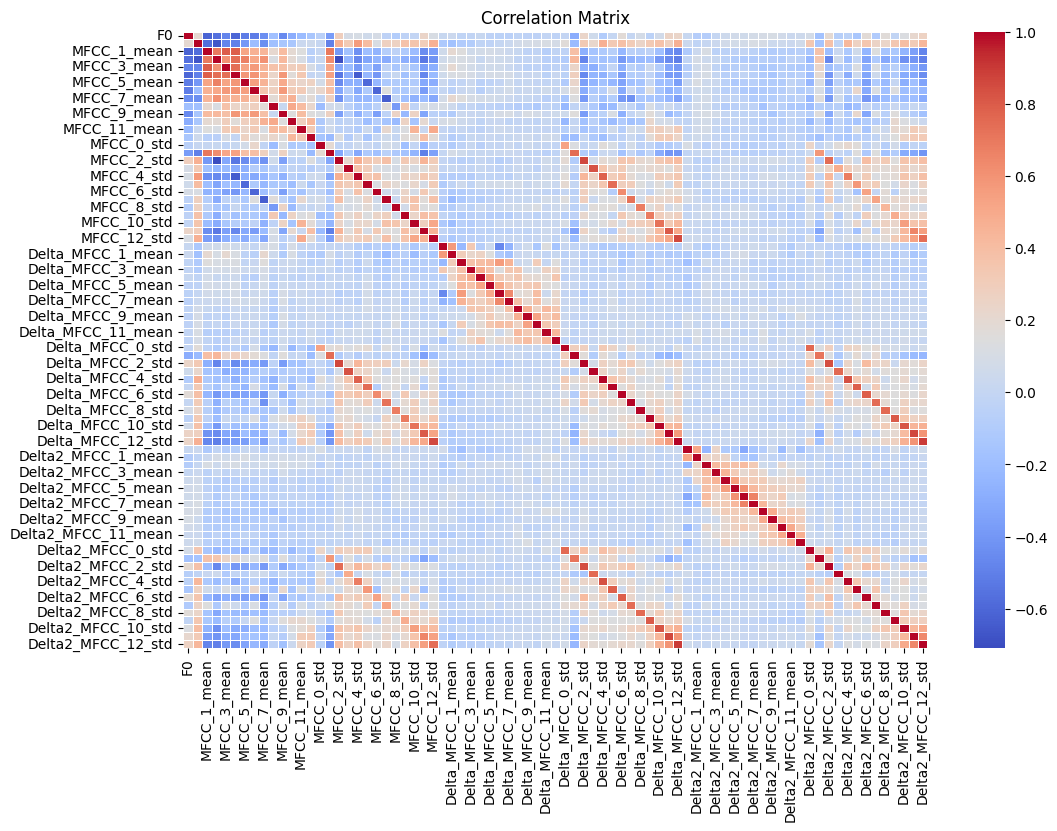

Explained Variance Ratio of PCA components: [0.15740099 0.07077618 0.0669143  0.05436597 0.04675467 0.03766577
 0.03295812 0.03066098 0.02871247 0.02684215 0.02544592 0.02317896
 0.0220611  0.02047614 0.01872948 0.01813218 0.01728567 0.01590153
 0.0149014  0.01356884 0.01323274 0.01254411 0.0118725  0.01112281
 0.01028327 0.01014599 0.00964704 0.0091015  0.00866017 0.00856621
 0.00829963 0.00795232 0.00754471 0.00724826 0.0070357  0.00632415
 0.00609254 0.00573837 0.00545859 0.00543136 0.00497218 0.00471788
 0.00468007 0.00425558 0.00414969 0.00395576 0.00362254 0.00347682
 0.00331746]
Shape of the data after PCA: (1440, 49)


In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv("mfcc_features_new.csv")

# Split the data into features and labels
X = data.drop(columns=['Label'])
y = data['Label']

# Step 1: Feature Scaling - Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: PCA - Dimensionality Reduction
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_pca = pca.fit_transform(X_scaled)

# Step 3: Correlation Analysis
corr_matrix = pd.DataFrame(X_scaled, columns=X.columns).corr()

# Plot the heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# Print the explained variance ratio of the principal components
print("Explained Variance Ratio of PCA components:", pca.explained_variance_ratio_)

# Check the shape of the reduced feature set
print("Shape of the data after PCA:", X_pca.shape)

# You can now use the transformed X_pca as input for further modeling


In [10]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Assuming the reduced PCA data is stored in `X_pca` and the labels are in `y`

# Step 1: Encode labels (if they are categorical)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42)

# Step 3: Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 4: Train the model
rf_model.fit(X_train, y_train)

# Step 5: Predict on the test set
y_pred = rf_model.predict(X_test)

# Step 6: Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of Random Forest model: {accuracy:.4f}')
print('Classification Report (Random Forest):')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy of Random Forest model: 0.4931
Classification Report (Random Forest):
                  precision    recall  f1-score   support

    female-angry       0.45      0.47      0.46        19
     female-calm       0.69      0.74      0.71        27
  female-disgust       0.56      0.50      0.53        18
  female-fearful       0.43      0.56      0.49        18
    female-happy       0.58      0.61      0.59        18
  female-neutral       0.33      0.12      0.18         8
      female-sad       0.40      0.40      0.40        15
female-surprised       0.68      0.60      0.64        25
      male-angry       0.87      0.57      0.68        23
       male-calm       0.34      0.76      0.47        17
    male-disgust       0.32      0.50      0.39        14
    male-fearful       0.44      0.50      0.47        14
      male-happy       0.30      0.38      0.33        16
    male-neutral       0.25      0.08      0.12        12
        male-sad       0.60      0.25      0.35   

In [11]:
# Import necessary libraries
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Assuming the reduced PCA data is stored in `X_pca` and the labels are in `y`

# Step 1: Encode labels (if they are categorical)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42)

# Step 3: Initialize the SVM model
svm_model = SVC(kernel='linear', random_state=42)  # Using linear kernel, you can try other kernels (e.g., 'rbf')

# Step 4: Train the model
svm_model.fit(X_train, y_train)

# Step 5: Predict on the test set
y_pred = svm_model.predict(X_test)

# Step 6: Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of SVM model: {accuracy:.4f}')
print('Classification Report (SVM):')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy of SVM model: 0.5521
Classification Report (SVM):
                  precision    recall  f1-score   support

    female-angry       0.65      0.58      0.61        19
     female-calm       0.70      0.85      0.77        27
  female-disgust       0.68      0.72      0.70        18
  female-fearful       0.52      0.67      0.59        18
    female-happy       0.65      0.72      0.68        18
  female-neutral       0.33      0.38      0.35         8
      female-sad       0.47      0.47      0.47        15
female-surprised       0.82      0.56      0.67        25
      male-angry       0.68      0.57      0.62        23
       male-calm       0.48      0.59      0.53        17
    male-disgust       0.35      0.50      0.41        14
    male-fearful       0.47      0.57      0.52        14
      male-happy       0.57      0.50      0.53        16
    male-neutral       0.33      0.42      0.37        12
        male-sad       0.46      0.25      0.32        24
  male-surpr

In [12]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Assuming the reduced PCA data is stored in `X_pca` and the labels are in `y`

# Step 1: Encode labels (if they are categorical)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42)

# Step 3: Build the Neural Network model
model = Sequential()

# Input layer + First hidden layer with ReLU activation
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.3))  # Dropout to prevent overfitting

# Second hidden layer with ReLU activation
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output layer (number of emotions/labels)
model.add(Dense(len(label_encoder.classes_), activation='softmax'))  # Softmax for multi-class classification

# Step 4: Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 6: Evaluate the model's performance on the test set
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=-1)  # Convert probabilities to class predictions

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print(f'Accuracy of Neural Network model: {accuracy:.4f}')
print('Classification Report (Neural Network):')
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))



C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0696 - loss: 2.9527 - val_accuracy: 0.1840 - val_loss: 2.5677
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1486 - loss: 2.6130 - val_accuracy: 0.2743 - val_loss: 2.3755
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2314 - loss: 2.3865 - val_accuracy: 0.3229 - val_loss: 2.1800
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2869 - loss: 2.1508 - val_accuracy: 0.3333 - val_loss: 1.9847
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3633 - loss: 1.9404 - val_accuracy: 0.3819 - val_loss: 1.8426
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3847 - loss: 1.8333 - val_accuracy: 0.4201 - val_loss: 1.7122
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3877 - loss: 1.7323 - val_accuracy: 0.4201 - val_loss: 1.6303
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4429 - loss: 1.6433 - val_accuracy: 0.4479 - val_loss